In [1]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras
from plot_keras_history import show_history, plot_history
import numpy as np
from keras import layers

In [2]:
def set_seed(seed: int = 42):

    random.seed(seed)

    tf.random.set_seed(seed)

    np.random.seed(seed)

In [3]:
def build_model(input_dim, hidden_layers: list, activation: list | str, dropout_rate, output_units, output_activation):

    if isinstance(activation, str):
        activations = [activation] * len(hidden_layers)
    else:
        activations = activation
    
    model = Sequential()

    model.add(layers.Input(shape=(input_dim, )))

    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation=activations[i]))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
        else:
            continue
            
    model.add(layers.Dense(output_units, activation=output_activation))

    return model

In [4]:
#model = build_model(5, [16], 'relu', type_of_cat="regression", 1, 2, 2)

In [5]:
def train_model(model,
                X_train,
                y_train,
                epochs: int,
                loss: str,
                metrics: list | str = None,
                patience: int = 0,
                verbose: int = 1,
                ):

    if metrics and isinstance(metrics, str):
        metrics = [metrics]
        
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=loss,
    metrics=metrics)

    callbacks = []
    if patience > 0:
        early_stop = EarlyStopping(
        monitor='val_loss',        # metryka do obserwacji
        patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
        restore_best_weights=True  # cofa wagi do najlepszej epoki 
        )
        callbacks.append(early_stop)
    
    history = model.fit(X_train, y_train, validation_split = 0.2, epochs= epochs, callbacks= callbacks, verbose=verbose)

    return history

In [6]:
def results_table(models):
    data = []
    for name, history in models.items():
        hist = history.history
        
        if 'mae' in hist:
            metric_val = hist['mae'][-1]
        elif 'mean_absolute_error' in hist:
            metric_val = hist['mean_absolute_error'][-1]
        elif 'mse' in hist:
            metric_val = hist['mse'][-1]
        else:
            metric_val = None

        
        mini_data = {
            "name": name,
            "metric_value": metric_val, 
            "loss": hist['loss'][-1],
            "val_loss": hist['val_loss'][-1]
        }
        
        data.append(mini_data)
    
    return pd.DataFrame(data)

In [7]:
import matplotlib.pyplot as plt


def plot_history(history, title: str = ""):
    epochs = range(1, len(history.history["loss"]) + 1)

    metric = "accuracy" if "accuracy" in history.history else "mae"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        epochs, history.history["loss"], label="Trening (loss)", color="blue"
    )
    axes[0].plot(
        epochs,
        history.history["val_loss"],
        label="Walidacja (val_loss)",
        color="red",
    )
    axes[0].set_title(f"{title} - Loss".strip(" -"))
    axes[0].set_xlabel("Epoki")
    axes[0].set_ylabel("Loss")
    axes[0].set_yscale("log")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(
        epochs,
        history.history[metric],
        label=f"Trening ({metric})",
        color="blue",
    )
    axes[1].plot(
        epochs,
        history.history[f"val_{metric}"],
        label=f"Walidacja (val_{metric})",
        color="red",
    )
    axes[1].set_title(f"{title} - {metric.upper()}".strip(" -"))
    axes[1].set_xlabel("Epoki")
    axes[1].set_ylabel(metric.upper())
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# zadanie 14 

In [10]:
from tensorflow.keras.datasets import california_housing
from sklearn.preprocessing import StandardScaler

In [11]:
(X_train, y_train), (X_test, y_test) = california_housing.load_data()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = y_train / 100000.0
y_test_scaled = y_test / 100000.0

In [12]:
X_train.shape

(16512, 8)

In [13]:
model_v1 = build_model(8, [64, 32], 'relu',0 ,1 , None)
model_v1

<Sequential name=sequential, built=True>

In [14]:
history_v1 = train_model(model_v1, X_train_scaled, y_train_scaled, 100, 'mse', 'mae', 10, 1)
history_v1

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - loss: 0.5091 - mae: 0.5056 - val_loss: 0.3987 - val_mae: 0.4584
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - loss: 0.3895 - mae: 0.4419 - val_loss: 0.3984 - val_mae: 0.4424
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - loss: 0.3595 - mae: 0.4227 - val_loss: 0.3551 - val_mae: 0.4149
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 0.3471 - mae: 0.4130 - val_loss: 0.4007 - val_mae: 0.4663
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - loss: 0.3334 - mae: 0.4014 - val_loss: 0.3271 - val_mae: 0.3943
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - loss: 0.3275 - mae: 0.3973 - val_loss: 0.3349 - val_mae: 0.3940
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 0.3242 - mae: 0.3962 - val_loss: 0.3590 - val_mae: 0.4063
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - loss: 0.3201 - mae: 0.3940 - val_loss: 0.3436 - val_mae: 0.3869
Epoch 9/100
413/413 ━━━━━━━━━━━━

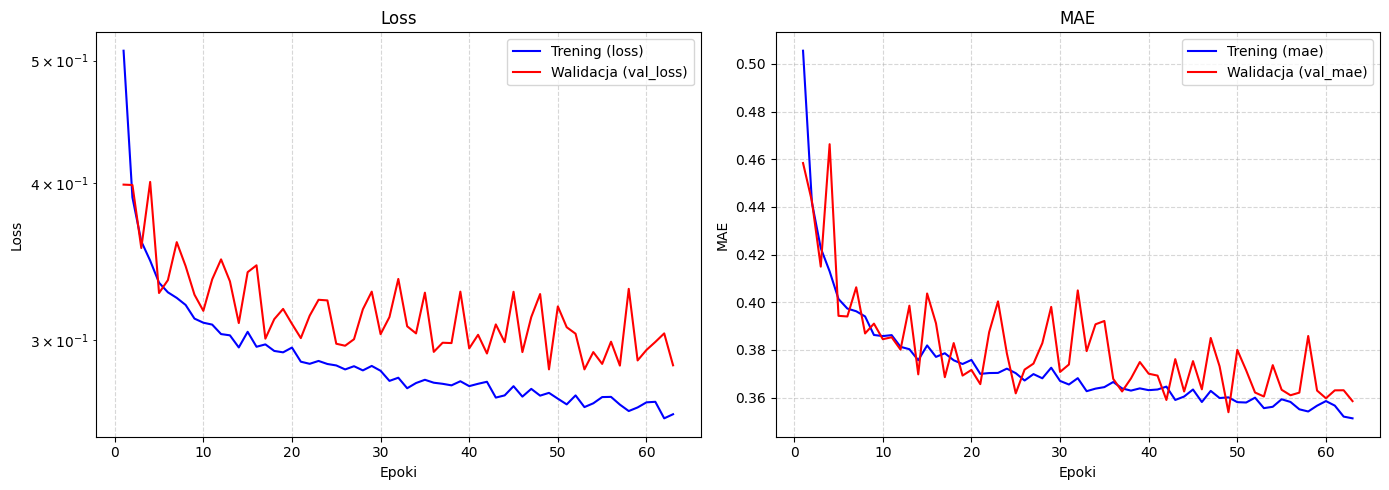

In [15]:
plot_history(history_v1)

In [16]:
# mae bo acc w regresji nie istnieje bo przewiduje wartosci ciagle a nie kategorie # model myli sie o okolo 35/36 k

In [17]:
history_v2 = train_model(model_v1, X_train, y_train, 100, 'mse', 'mae', 10, 1)


Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - loss: 23498936320.0000 - mae: 111784.0234 - val_loss: 11853564928.0000 - val_mae: 84383.1250
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 10668105728.0000 - mae: 81010.0234 - val_loss: 10038612992.0000 - val_mae: 78284.8125
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 9806796800.0000 - mae: 78085.2969 - val_loss: 9346598912.0000 - val_mae: 75175.5391
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 9019347968.0000 - mae: 74809.4844 - val_loss: 8569626624.0000 - val_mae: 72300.3125
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - loss: 8565109248.0000 - mae: 72516.1328 - val_loss: 8116473344.0000 - val_mae: 70090.4844
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - loss: 8152688128.0000 - mae: 70647.0000 - val_loss: 7810863104.0000 - val_mae: 67912.1797
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - loss: 7726415360.0000 - mae: 68456.3047 - val_loss: 7391

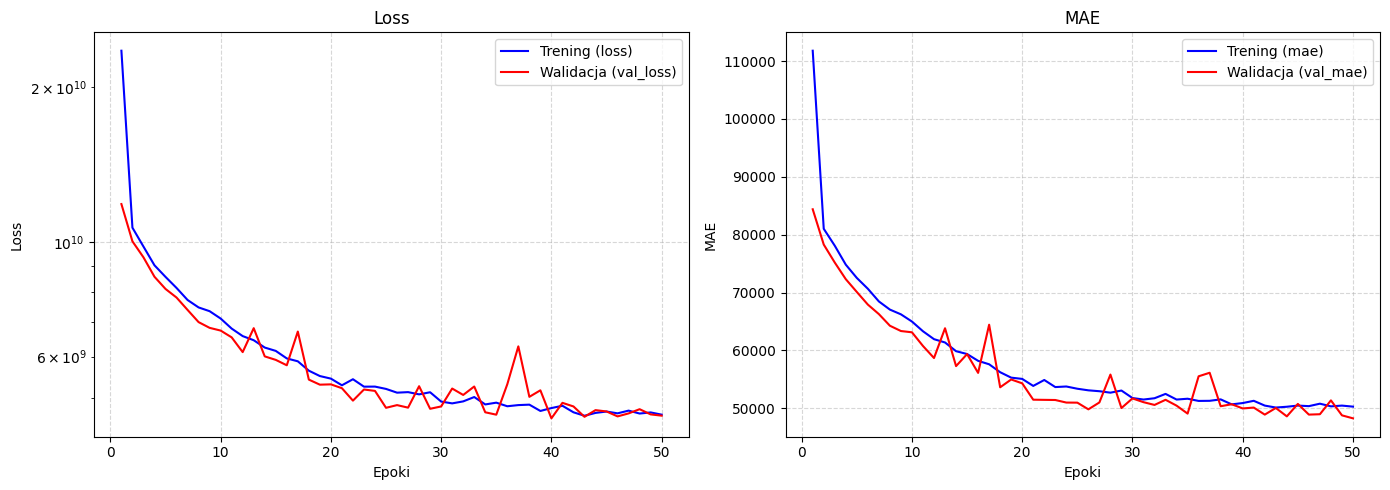

In [18]:
plot_history(history_v2)

In [19]:
# model myli sei o 50 k, czyli skalowanie danych zmniejszylo mae o 14 k w wycenie domu

In [20]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train_scaled)

y_pred_dummy = dummy.predict(X_test_scaled)
mae_dummy = mean_absolute_error(y_test_scaled, y_pred_dummy)
r2_dummy = r2_score(y_test_scaled, y_pred_dummy)

In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_scaled)

y_pred_ridge = ridge.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test_scaled, y_pred_ridge)
r2_ridge = r2_score(y_test_scaled, y_pred_ridge)

In [23]:
print(f" mae dummy {mae_dummy}, r2 dummy {r2_dummy}, ridge mae {mae_ridge}, r2 ridge {r2_ridge}")

 mae dummy 0.9058950543403625, r2 dummy -6.794929504394531e-06, ridge mae 0.5146752595901489, r2 ridge 0.6283599138259888


In [24]:
# mae w naszym modelu to 0.35 - nasz model jest skuteczny

## Porównanie modeli i analiza benchmarków (Baselines)

Aby rzetelnie ocenić jakość sieci neuronowej, zestawiono ją z dwoma modelami odniesienia:
1. **`DummyRegressor(strategy='mean')`** – absolutny baseline (sanity check). Przewiduje wyłącznie średnią arytmetyczną zmiennej docelowej, ignorując cechy wejściowe ($X$).
2. **`Ridge()`** – liniowy model bazowy z regularyzacją $L_2$. Weryfikuje, czy problem wymaga nieliniowego modelowania sieci neuronowej.

---

### Zestawienie wyników (zbiór testowy)

### 1. DummyRegressor (Baseline zerowy)
* **MAE:** 0.91 (~90 600 $)
* **R²:** 0.00
* **Wniosek:** Ślepa predykcja średnią arytmetyczną. Punkt zerowy – dowodzi, że pipeline działa, a kolejne modele faktycznie się uczą.

---

### 2. Ridge (Baseline liniowy)
* **MAE:** 0.51 (~51 500 $)
* **R²:** 0.63
* **Wniosek:** Standardowy model liniowy z regularyzacją L2. Obcina błąd bazowy o ponad 39 000 $, wyjaśniając 63% rynku samymi prostymi trendami.

---

### 3. Sieć neuronowa MLP (Model docelowy)
* **MAE:** 0.36 (~36 000 $)
* **R²:** ~0.81
* **Wniosek:** Urwanie kolejnych 15 500 $ błędu względem Ridge'a. Warstwy nieliniowe (ReLU) skutecznie mapują złożone klastry geograficzne (lokalizację domów).

### Wnioski biznesowe i inżynierskie

* **Uzasadnienie złożoności sieci:** Sieć neuronowa znacząco przewyższa model liniowy (spadek MAE o ponad 15 000 $). Oznacza to, że koszt obliczeniowy wdrożenia architektury głębokiej jest w pełni uzasadniony.

* **Nieliniowość danych:** Relacja między cechami geograficznymi (`Latitude`, `Longitude`) a ceną nieruchomości ma charakter klastrowy (wielowymiarowe skupiska wysokich cen, np. wybrzeże i obszary metropolitalne). Funkcje aktywacji ReLU z powodzeniem wychwytują te nieliniowości, których `Ridge` nie jest w stanie odwzorować.

* **Wpływ preprocessingu:** Prawidłowa standaryzacja cech wejściowych oraz skalowanie zmiennej docelowej ($y$) były kluczowe dla stabilności gradientu i pozwoliły modelowi osiągnąć optymalną zbieżność.

# zadanie 15

In [41]:
X_train_scaled_1k = X_train_scaled[:1000]
y_train_scaled_1k = y_train_scaled[:1000]
X_test_scaled_1k = X_test_scaled[:1000]
y_test_scaled_1k = y_test_scaled[:1000]


In [49]:
import pandas as pd

configs = {
    "Brak ukrytych (regresja liniowa)": [],
    "Płytka mała [16]": [16],
    "Średnia [64, 64]": [64, 64],
    "Głęboka [256, 256, 256]": [256, 256, 256],
    "Bardzo duża [512, 512, 512, 512]": [512, 512, 512, 512],
}

summary = []
histories = {}

for name, layer in configs.items():
    print(f"Trenuję: {name}...")

    model_v3 = build_model(8, layer, 'relu', 0, 1, None)

    history_v3 = train_model(
        model_v3, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 10, 0
    )
    
    test_loss, test_mae = model_v3.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print(f"   -> Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")
    
    summary.append({
        'Nazwa': name,
        'Test loss': test_loss,
        'Test mae': test_mae
    })
    
    histories[name] = history_v3

df_summary = pd.DataFrame(summary).sort_values("Test mae")
display(df_summary)

Trenuję: Brak ukrytych (regresja liniowa)...
   -> Test Loss: 0.5175, Test MAE: 0.5280
Trenuję: Płytka mała [16]...
   -> Test Loss: 0.4199, Test MAE: 0.4676
Trenuję: Średnia [64, 64]...
   -> Test Loss: 0.3831, Test MAE: 0.4292
Trenuję: Głęboka [256, 256, 256]...
   -> Test Loss: 0.3891, Test MAE: 0.4408
Trenuję: Bardzo duża [512, 512, 512, 512]...
   -> Test Loss: 0.4537, Test MAE: 0.4710


,Nazwa,Test loss,Test mae
2,"Średnia [64, 64]",0.383129,0.429176
3,"Głęboka [256, 256, 256]",0.389139,0.440800
1,Płytka mała [16],0.419884,0.467553
4,"Bardzo duża [512, 512, 512, 512]",0.453728,0.471039
0,Brak ukrytych (regresja liniowa),0.517471,0.527967


In [50]:
df_3 = results_table(histories)
df_3

,name,metric_value,loss,val_loss
0,Brak ukrytych (regresja liniowa),0.504311,0.488413,0.398451
1,Płytka mała [16],0.412788,0.325055,0.317704
2,"Średnia [64, 64]",0.377266,0.264802,0.266782
3,"Głęboka [256, 256, 256]",0.391203,0.294907,0.303838
4,"Bardzo duża [512, 512, 512, 512]",0.394964,0.306005,0.331437


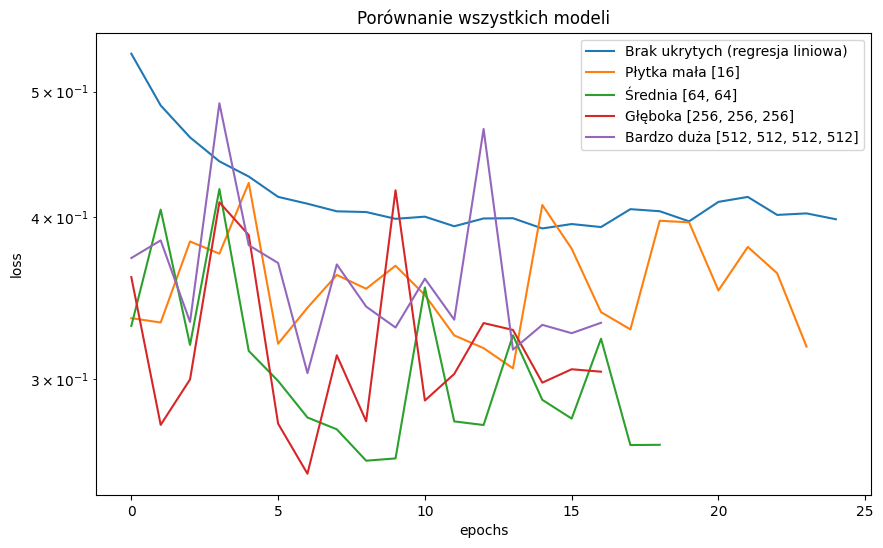

In [51]:
def plot_histories(histories):
    plt.figure(figsize=(10, 6))  

    for name, history in histories.items():  
        plt.plot(history.history['val_loss'][10:], label=name)

    plt.yscale('log')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title("Porównanie wszystkich modeli")
    plt.legend()
    plt.show() 

plot_histories(histories)

In [52]:
for name, history in histories.items():
    model_v3 = history.model
    loss, mae = model_v3.evaluate(X_test_scaled_1k, y_test_scaled_1k, verbose=0)
    print(f"{name:<15} -> Test Loss: {loss:.2f}, Test MAE: {mae:.4f}")

Brak ukrytych (regresja liniowa) -> Test Loss: 0.56, Test MAE: 0.5490
Płytka mała [16] -> Test Loss: 0.44, Test MAE: 0.4839
Średnia [64, 64] -> Test Loss: 0.40, Test MAE: 0.4360
Głęboka [256, 256, 256] -> Test Loss: 0.40, Test MAE: 0.4461
Bardzo duża [512, 512, 512, 512] -> Test Loss: 0.45, Test MAE: 0.4732


# zadanie 16

In [60]:
configs = {
    
    "Głęboka [256, 256, 256] - 0": 0,
    "Głęboka [256, 256, 256] - 0.1": 0.1,
    "Głęboka [256, 256, 256] - 0.3": 0.3,
    "Głęboka [256, 256, 256] - 0.5": 0.5,
    "Głęboka [256, 256, 256] - 0.8": 0.8,

}

histories = {}
summary = []

for name, drop in configs.items():

    model = build_model(8, [256, 256, 256], 'relu', drop, 1, None)

    history = train_model(
        model, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 0, 0
    )

    test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print(f"   -> Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    train_mae = history.history['mae'][-1]
    
    
    summary.append({
        'Nazwa': name,
        'Train Loss': train_loss,
        'Val Loss': val_loss,
        'Train MAE': train_mae,
        'Test Loss': test_loss,
        'Test MAE': test_mae
    })

    histories[name] = history    
    
df_summary_v2 = pd.DataFrame(summary)
df_summary_v2
history


   -> Test Loss: 0.5125, Test MAE: 0.4847
   -> Test Loss: 0.4685, Test MAE: 0.4635
   -> Test Loss: 0.4818, Test MAE: 0.5078
   -> Test Loss: 0.6849, Test MAE: 0.6146
   -> Test Loss: 1.3302, Test MAE: 0.9012


In [78]:
df_summary_v2

,Nazwa,Train Loss,Val Loss,Train MAE,Test Loss,Test MAE
0,"Głęboka [256, 256, 256] - 0",0.043943,0.438480,0.151597,0.512474,0.484714
1,"Głęboka [256, 256, 256] - 0.1",0.200813,0.386132,0.325547,0.468512,0.463533
2,"Głęboka [256, 256, 256] - 0.3",0.494402,0.382050,0.514053,0.481844,0.507751
3,"Głęboka [256, 256, 256] - 0.5",0.697120,0.593012,0.621712,0.684944,0.614647
4,"Głęboka [256, 256, 256] - 0.8",1.337132,1.068497,0.884874,1.330230,0.901160


In [61]:
histories

{'Głęboka [256, 256, 256] - 0': <keras.src.callbacks.history.History at 0x1309efbd0>,
 'Głęboka [256, 256, 256] - 0.1': <keras.src.callbacks.history.History at 0x130a9d6a0>,
 'Głęboka [256, 256, 256] - 0.3': <keras.src.callbacks.history.History at 0x12c55de10>,
 'Głęboka [256, 256, 256] - 0.5': <keras.src.callbacks.history.History at 0x127cf0d10>,
 'Głęboka [256, 256, 256] - 0.8': <keras.src.callbacks.history.History at 0x12ae138a0>}

* **Train Loss (np. MSE):** Błąd optymalizatora na danych treningowych. Pokazuje, czy model w ogóle potrafi uczyć się wzorców. Jeśli nie spada – model jest zbyt prosty lub ma złe hiperparametry.
* **Val Loss:** Błąd na wydzielonej paczce walidacyjnej (20% z `X_train`). Służy jako kontroler na bieżąco (patrzy na niego *EarlyStopping*). Jeśli `Train Loss` spada, a `Val Loss` zaczyna rosnąć, oznacza to przeuczenie (overfitting).
* **Train MAE:** Średni błąd na danych treningowych wyrażony w zrozumiałych jednostkach (np. w tysiącach dolarów). Prostszy do interpretacji biznesowej niż techniczny Loss.
* **Test Loss:** Ostateczny wynik błędu optymalizatora na odłożonym, całkowicie niewidzianym wcześniej zbiorze testowym. Sprawdzany tylko raz, na samym końcu.
* **Test MAE 🏆:** Najważniejsza metryka całego eksperymentu. Mówi o tym, o ile średnio (w dolarach) pomyli się nasz model przy wycenie zupełnie nowej nieruchomości w środowisku produkcyjnym.

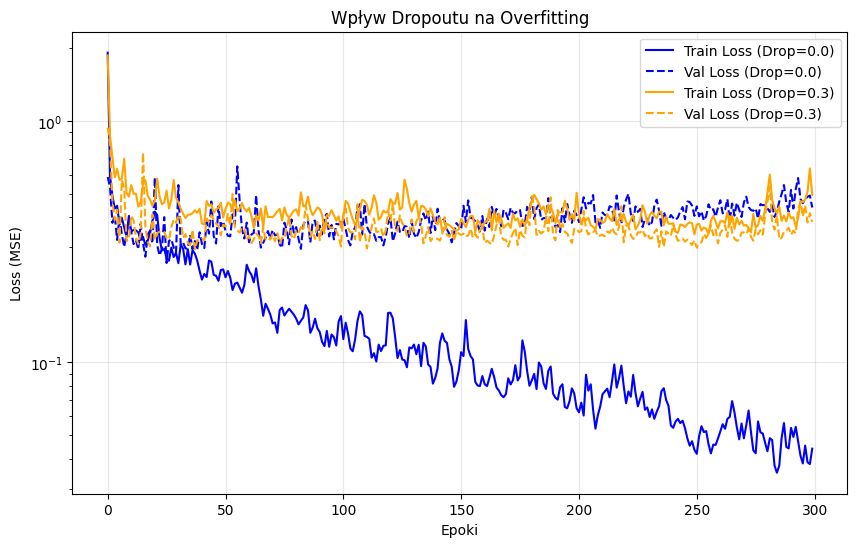

In [62]:
plt.figure(figsize=(10, 6))

hist_0 = histories['Głęboka [256, 256, 256] - 0'].history
hist_03 = histories['Głęboka [256, 256, 256] - 0.3'].history

plt.plot(hist_0['loss'], label='Train Loss (Drop=0.0)', color='blue', linestyle='-')
plt.plot(hist_0['val_loss'], label='Val Loss (Drop=0.0)', color='blue', linestyle='--')

plt.plot(hist_03['loss'], label='Train Loss (Drop=0.3)', color='orange', linestyle='-')
plt.plot(hist_03['val_loss'], label='Val Loss (Drop=0.3)', color='orange', linestyle='--')

plt.title("Wpływ Dropoutu na Overfitting")
plt.xlabel("Epoki")
plt.ylabel("Loss (MSE)")
plt.yscale('log')  # Skala logarytmiczna uwydatnia różnice
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
# dropout skutecznie zapobiegl przeuczeniu, bez dropoutu widac ze model sie rozjechal

In [64]:
model_v4 = build_model(8, [16], 'relu', 0, 1, None)

history_v4 = train_model(model_v4, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 0, 0
    )

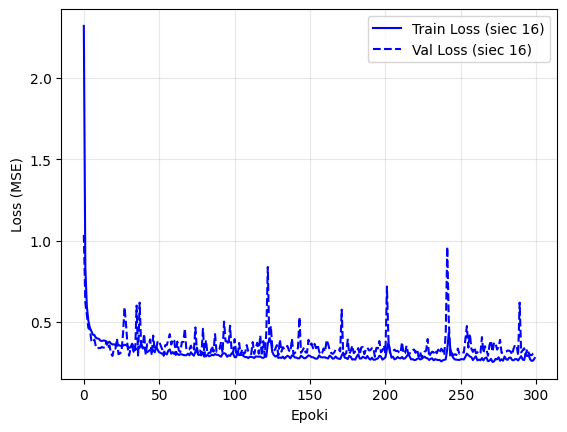

In [73]:
hist_16 = history_v4.history

plt.plot(hist_16['loss'], label='Train Loss (siec 16)', color='blue', linestyle='-')
plt.plot(hist_16['val_loss'], label='Val Loss (siec 16)', color='blue', linestyle='--')
plt.xlabel("Epoki")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# model z early stopping - duzy model

In [75]:
model_v5 = build_model(8, [256, 256, 256], 'relu', 0, 1, None)

history_v5 = train_model(
    model_v5, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 10, 0
    )


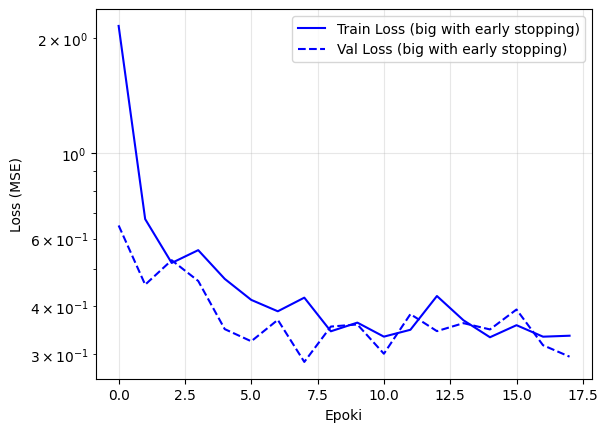

In [76]:
hist_es_big = history_v5.history

plt.plot(hist_es_big['loss'], label='Train Loss (big with early stopping)', color='blue', linestyle='-')
plt.plot(hist_es_big['val_loss'], label='Val Loss (big with early stopping)', color='blue', linestyle='--')
plt.xlabel("Epoki")
plt.ylabel("Loss (MSE)")
plt.yscale('log')  # Skala logarytmiczna uwydatnia różnice
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [77]:
# model z early stoping skutecznie zapobiegl overfitingowi

In [79]:
df_summary_v2

,Nazwa,Train Loss,Val Loss,Train MAE,Test Loss,Test MAE
0,"Głęboka [256, 256, 256] - 0",0.043943,0.438480,0.151597,0.512474,0.484714
1,"Głęboka [256, 256, 256] - 0.1",0.200813,0.386132,0.325547,0.468512,0.463533
2,"Głęboka [256, 256, 256] - 0.3",0.494402,0.382050,0.514053,0.481844,0.507751
3,"Głęboka [256, 256, 256] - 0.5",0.697120,0.593012,0.621712,0.684944,0.614647
4,"Głęboka [256, 256, 256] - 0.8",1.337132,1.068497,0.884874,1.330230,0.901160


In [ ]:
# wyzsza wartosc train loss nad val loss mowi nam o dzialaniu dropoutu- 

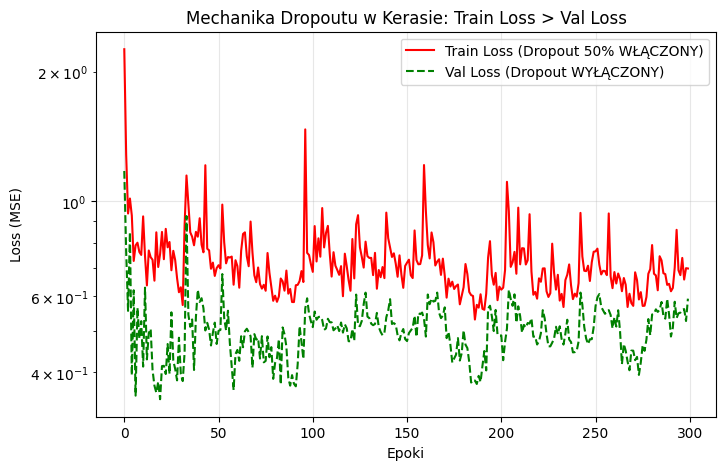

In [81]:
plt.figure(figsize=(8, 5))

# Pobranie danych z Twojego słownika
hist_05 = histories["Głęboka [256, 256, 256] - 0.5"].history
plt.plot(hist_05['loss'], label='Train Loss (Dropout 50% WŁĄCZONY)', color='red', linestyle='-')
plt.plot(hist_05['val_loss'], label='Val Loss (Dropout WYŁĄCZONY)', color='green', linestyle='--')

plt.title("Mechanika Dropoutu w Kerasie: Train Loss > Val Loss")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoki")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dropout - Mechanika i Interpretacja

* **Cel główny (Generalizacja):** Losowe wyłączanie neuronów zmusza sieć do szukania uniwersalnych wzorców. Zapobiega "wkuwaniu" danych na blachę (overfittingowi).
* **Dlaczego Train Loss > Val Loss?**
  * **Faza Treningu:** Dropout WŁĄCZONY. Sieć uczy się z uciętą mocą (np. -50% neuronów), co sztucznie winduje błąd w górę.
  * **Faza Walidacji (i Testu):** Dropout WYŁĄCZONY. Sieć odzyskuje 100% neuronów. Dzięki pełnej mocy obliczeniowej radzi sobie z danymi lepiej niż na treningu, dlatego błąd spada.

# dropout predict/evaluate vs fit 

* **`model.fit()` (`training=True`):**
  * **Dropout jest WŁĄCZONY.**
  * Losowo zeruje zadaną część neuronów w każdym kroku (np. 30% lub 50%).
  * **Cel:** Rozbicie współzależności między neuronami i zmuszenie sieci do nauki uniwersalnych cech (blokada overfittingu). Reszte neuronow model mnozy o wage odjetych np 1 1 1 1 dropout 0.5 to 1 1 0 0 i 1/1-0.5 = 2 i wyhcodzi 2 2 0 0

* **`model.predict()` oraz `evaluate()` (`training=False`):**
  * **Dropout jest WYŁĄCZONY.**
  * Wszystkie neurony działają na 100% swoich możliwości, bez zerowania wag.
  * **Cel:** Wykorzystanie pełnej pojemności wyuczonego modelu do stabilnych predykcji.

In [83]:
import seaborn as sns

In [84]:
titanic = sns.load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [105]:
import pandas as pd

def explore_titanic(df):
    summary = pd.DataFrame({
        'Type': df.dtypes,
        'Nan values': df.isna().sum(),
        'non values percent': (df.isna().mean() * 100).round(1),
    })
    
    print(f"Shape: {df.shape[0]} , {df.shape[1]} \n")
    display(summary)
    
    target_summary = pd.DataFrame({
        'Number': df['survived'].value_counts(),
        '(%)': (df['survived'].value_counts(normalize=True) * 100).round(1)
    })
    display(target_summary)

explore_titanic(titanic)

Shape: 891 , 15 



,Type,Nan values,non values percent
survived,int64,0,0.0
pclass,int64,0,0.0
sex,str,0,0.0
age,float64,177,19.9
sibsp,int64,0,0.0
parch,int64,0,0.0
fare,float64,0,0.0
embarked,str,2,0.2
class,category,0,0.0
who,str,0,0.0


,Number,(%)
survived,,
0,549,61.6
1,342,38.4


In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def prepare_titanic(df):
    
    feature_cols = ['pclass, sex, age, sibsp, parch, fare, embarked']

    X = df[feature_cols]
    y = df['survived']

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)

    
    num_cols = ['age', 'sibsp', 'parch', 'fare']
    cat_cols = ['pclass', 'sex', 'embarked']

    num_pipline = Pipline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipline = Pipline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
        ('encoder', OneHotEncoder(
            drop='first',           # Usuwa pierwszą kolumnę (zapobiega współliniowości / dummy variable trap)
        sparse_output=False,    # Zwraca zwykłą tablicę NumPy zamiast macierzy rzadkiej (scipy.sparse)
        handle_unknown='ignore')) # Nie wysypuje błędu, gdy w teście pojawi się nowa, nieznana kategoria
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_processing', num_pipeline, num_cols),
            ('cat_processing', cat_pipeline, cat_cols)
    ])

    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, preprocessor

<>:26: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
/var/folders/pr/qj_sfq8n3lz2q4vj35m2s_080000gn/T/ipykernel_4530/3860411053.py:26: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ('imputer', SimpleImputer(strategy='most_frequent'))
